## threshscore  -  Complete End-to-End Showcase

**threshscore** is a library for threshold-aware binary classification scoring.
It answers the question: *"Given that we need ≥ X% sensitivity AND ≥ Y% specificity, how well does this model perform?"*

## What you'll learn

| Section | Topics |
|---------|--------|
| **1. Setup & Data** | Installation, imports, synthetic data |
| **2. Scoring API** | `score_from_metrics`, `score_from_predictions`, `score_from_scores` |
| **3. Metrics API** | `compute_metrics`, `ClassificationMetrics` |
| **4. Gate Functions** | All 4 built-ins: arctan, sigmoid, relu_clip, linear_clip |
| **5. Visualization** | All 6 plot types |
| **6. Threshold Sweep** | `sweep()`, `ThresholdSweep` methods |
| **7. Custom Gate Functions** | Writing and registering your own gate function |
| **8. Summary** | Full API reference table |

Install: `pip install threshscore`

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import threshscore
from threshscore import (
    score_from_metrics,
    score_from_predictions,
    score_from_scores,
    compute_metrics,
    sweep,
    plot,
    gates,
)

print(f"threshscore version: {threshscore.__version__}")

threshscore version: 0.1.0


## 2. Sample Data

We simulate a **medical screening** scenario  -  200 patients, 30% positive rate.
Positive patients produce higher model scores on average (Beta(5, 2) vs Beta(2, 5)).

In [2]:
rng = np.random.default_rng(42)
n = 200

# Ground-truth labels: 30% positive
y_true = rng.binomial(1, 0.3, size=n)

# Predicted probability scores
y_score = np.where(
    y_true == 1,
    rng.beta(5, 2, size=n),   # positive class: skewed high
    rng.beta(2, 5, size=n),   # negative class: skewed low
)

# Hard predictions at the default decision threshold of 0.5
y_pred = (y_score >= 0.5).astype(int)

n_pos = int(y_true.sum())
n_neg = n - n_pos
print(f"Total samples : {n}")
print(f"Positives     : {n_pos}  ({100*n_pos/n:.0f}%)")
print(f"Negatives     : {n_neg}  ({100*n_neg/n:.0f}%)")

Total samples : 200
Positives     : 58  (29%)
Negatives     : 142  (71%)


## 3. Scoring API

threshscore provides three entry points that all compute the same centering-based score,
but accept different input formats.

### Formula

```
q        = 0.5 * (sensitivity + specificity)
gate_s   = gate(sensitivity, s_thr)
gate_p   = gate(specificity, p_thr)
gate     = gate_s × gate_p
gate_thr = gate(s_thr, s_thr) × gate(p_thr, p_thr)
q_thr    = 0.5 * (s_thr + p_thr)
score    = clip(0.5 + 0.5*(gate − gate_thr) + 0.5*(q − q_thr), 0, 1)
```

**Key property:** score = 0.5 exactly at the operating point; > 0.5 when both metrics exceed thresholds.

### 3a. `score_from_metrics(sens, spec, ...)`

The simplest form  -  pass sensitivity and specificity directly (no raw data needed).
Returns a `float` in [0, 1].

In [3]:
# Suppose we know the achieved sensitivity and specificity from a report
achieved_sens = 0.89
achieved_spec = 0.86

# Defaults: s_thr=0.80, p_thr=0.60, gate="arctan"
score_basic = score_from_metrics(achieved_sens, achieved_spec)
print(f"Default thresholds (s_thr=0.80, p_thr=0.60): score = {score_basic:.4f}")

# Custom thresholds  -  stricter requirements
score_strict = score_from_metrics(
    achieved_sens, achieved_spec,
    s_thr=0.90,
    p_thr=0.80,
)
print(f"Strict thresholds  (s_thr=0.90, p_thr=0.80): score = {score_strict:.4f}")

# At the operating point exactly → score == 0.5 by definition
score_at_thr = score_from_metrics(0.80, 0.60, s_thr=0.80, p_thr=0.60)
print(f"\nAt operating point (sens=s_thr, spec=p_thr): score = {score_at_thr:.4f}  (always 0.5)")

# Below both thresholds → score < 0.5
score_below = score_from_metrics(0.60, 0.40, s_thr=0.80, p_thr=0.60)
print(f"Below both thresholds:                        score = {score_below:.4f}  (< 0.5)")

Default thresholds (s_thr=0.80, p_thr=0.60): score = 0.8749
Strict thresholds  (s_thr=0.90, p_thr=0.80): score = 0.5590

At operating point (sens=s_thr, spec=p_thr): score = 0.5000  (always 0.5)
Below both thresholds:                        score = 0.2770  (< 0.5)


### 3b. `score_from_predictions(y_true, y_pred, ...)`

Accepts **binary predictions** (already thresholded).
Returns a `ScoreResult` with the score plus the full metrics object.

In [4]:
result_pred = score_from_predictions(
    y_true, y_pred,
    s_thr=0.85,
    p_thr=0.65,
    gate="arctan",
)

print(result_pred)
print()
print(f"Constrained score : {result_pred.score:.4f}")
print(f"Sensitivity       : {result_pred.sensitivity:.4f}  (target ≥ 0.85, gate = {result_pred.sensitivity_gate:.4f})")
print(f"Specificity       : {result_pred.specificity:.4f}  (target ≥ 0.65, gate = {result_pred.specificity_gate:.4f})")
print(f"Gate used         : {result_pred.gate_name}")

ScoreResult(score=0.8027, sensitivity=0.8966 (threshold=0.85, gate=0.7740), specificity=0.8592 (threshold=0.65, gate=0.9399), gate=arctan)

Constrained score : 0.8027
Sensitivity       : 0.8966  (target ≥ 0.85, gate = 0.7740)
Specificity       : 0.8592  (target ≥ 0.65, gate = 0.9399)
Gate used         : arctan


### 3c. `score_from_scores(y_true, y_score, threshold=0.5, ...)`

Accepts **probability scores** and binarises them at `threshold`.
Returns a `ScoreResult` that also includes ROC AUC and PR AUC (because probability scores are available).

Use this when you have continuous model outputs and want to explore different decision thresholds.

In [5]:
# Default decision threshold = 0.5
result = score_from_scores(
    y_true, y_score,
    s_thr=0.85,
    p_thr=0.65,
    gate="arctan",
)
print("Decision threshold = 0.50:")
print(result)
print()

# Try a lower decision threshold (more generous positives → higher sensitivity)
result_low = score_from_scores(
    y_true, y_score,
    threshold=0.35,
    s_thr=0.85,
    p_thr=0.65,
    gate="arctan",
)
print("Decision threshold = 0.35:")
print(result_low)
print()

# Inspect the full metrics bundle on the result
m = result.metrics
print(f"ROC AUC : {m.roc_auc:.4f}")
print(f"PR AUC  : {m.pr_auc:.4f}")

Decision threshold = 0.50:
ScoreResult(score=0.8027, sensitivity=0.8966 (threshold=0.85, gate=0.7740), specificity=0.8592 (threshold=0.65, gate=0.9399), gate=arctan)

Decision threshold = 0.35:
ScoreResult(score=0.6109, sensitivity=0.9483 (threshold=0.85, gate=0.8770), specificity=0.6479 (threshold=0.65, gate=0.4832), gate=arctan)

ROC AUC : 0.9513
PR AUC  : 0.9094


## 4. Classification Metrics

`compute_metrics(y_true, y_pred, y_score=None)` computes the full set of binary
classification metrics.  Pass `y_score` to also get ROC AUC and PR AUC.

In [6]:
m = compute_metrics(y_true, y_pred, y_score)

print(m)
print()
print("Individual fields:")
print(f"  sensitivity  : {m.sensitivity:.4f}  (= recall = TPR)")
print(f"  specificity  : {m.specificity:.4f}  (= TNR)")
print(f"  precision    : {m.precision:.4f}")
print(f"  recall       : {m.recall:.4f}")
print(f"  f1           : {m.f1:.4f}")
print(f"  accuracy     : {m.accuracy:.4f}")
print(f"  roc_auc      : {m.roc_auc:.4f}")
print(f"  pr_auc       : {m.pr_auc:.4f}")
print()
print("Confusion matrix (rows=true, cols=predicted):")
print(m.confusion_matrix)
print(f"  TN={m.confusion_matrix[0,0]:.0f}  FP={m.confusion_matrix[0,1]:.0f}")
print(f"  FN={m.confusion_matrix[1,0]:.0f}  TP={m.confusion_matrix[1,1]:.0f}")
print()
print(f"Sample counts: n={m.n_samples}, n_positive={m.n_positive}, n_negative={m.n_negative}")

ClassificationMetrics(sens=0.8966, spec=0.8592, prec=0.7222, recall=0.8966, f1=0.8000, acc=0.8700, roc_auc=0.9513, pr_auc=0.9094)

Individual fields:
  sensitivity  : 0.8966  (= recall = TPR)
  specificity  : 0.8592  (= TNR)
  precision    : 0.7222
  recall       : 0.8966
  f1           : 0.8000
  accuracy     : 0.8700
  roc_auc      : 0.9513
  pr_auc       : 0.9094

Confusion matrix (rows=true, cols=predicted):
[[122.  20.]
 [  6.  52.]]
  TN=122  FP=20
  FN=6  TP=52

Sample counts: n=200, n_positive=58, n_negative=142


### Standalone helpers

`sensitivity_score` and `specificity_score` are also available from `threshscore.core` for quick access.

In [7]:
from threshscore.core import sensitivity_score, specificity_score

sens = sensitivity_score(y_true, y_pred)
spec = specificity_score(y_true, y_pred)
print(f"Sensitivity: {sens:.4f}")
print(f"Specificity: {spec:.4f}")

Sensitivity: 0.8966
Specificity: 0.8592


## 5. Gate Functions

Gate functions are the **gate** that controls how sharply the score penalises
a model for falling below a metric threshold.

threshscore ships with four built-ins.  All are registered in the gate registry
and can be referenced by name string or passed as instances.

In [8]:
# List all registered gate functions
print("Registered gates:", gates.list_gates())

# Retrieve an instance by name
gate_fn = gates.get("arctan")
print(f"\narctan at 0.85 (threshold=0.80): gate = {gate_fn(0.85, 0.80):.4f}")
print(f"arctan at 0.80 (threshold=0.80): gate = {gate_fn(0.80, 0.80):.4f}  (always 0.5)")
print(f"arctan at 0.60 (threshold=0.80): gate = {gate_fn(0.60, 0.80):.4f}")

Registered gates: ['arctan', 'linear_clip', 'relu_clip', 'sigmoid']

arctan at 0.85 (threshold=0.80): gate = 0.7852
arctan at 0.80 (threshold=0.80): gate = 0.5000  (always 0.5)
arctan at 0.60 (threshold=0.80): gate = 0.0628


### 5a. `ArctanGate`  -  smooth, S-shaped gate

```
gate(value, threshold) = arctan(k × (value − threshold)) / π + 0.5
```

- Returns **0.5 exactly** at the threshold.
- Approaches 1 above, 0 below.
- Parameter **k** (default: 25.0) controls slope steepness.
- Larger k → sharper cliff around the threshold.

In [9]:
from threshscore.gates import ArctanGate

# Default parameters
gate_arctan = ArctanGate()
print("ArctanGate default_params:", gate_arctan.default_params)

# Evaluate at several points
print("\nGate values around threshold=0.80:")
for v in [0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 1.00]:
    g = gate_arctan(v, 0.80)
    bar = "█" * int(g * 20)
    print(f"  value={v:.2f}  gate={g:.4f}  {bar}")

# Override k to get a softer gate
print("\nSofter gate (k=5):")
for v in [0.60, 0.70, 0.75, 0.80, 0.85, 0.90]:
    g = gate_arctan(v, 0.80, k=5)
    print(f"  value={v:.2f}  gate={g:.4f}")

# Use in scoring API
score_arctan_default = score_from_metrics(0.85, 0.75, s_thr=0.80, p_thr=0.60, gate="arctan")
score_arctan_soft    = score_from_metrics(0.85, 0.75, s_thr=0.80, p_thr=0.60,
                                          gate="arctan", gate_params={"k": 5})
print(f"\nscore (arctan k=25, default): {score_arctan_default:.4f}")
print(f"score (arctan k=5, softer)  : {score_arctan_soft:.4f}")

ArctanGate default_params: {'k': 25.0}

Gate values around threshold=0.80:
  value=0.60  gate=0.0628  █
  value=0.70  gate=0.1211  ██
  value=0.75  gate=0.2148  ████
  value=0.80  gate=0.5000  ██████████
  value=0.85  gate=0.7852  ███████████████
  value=0.90  gate=0.8789  █████████████████
  value=1.00  gate=0.9372  ██████████████████

Softer gate (k=5):
  value=0.60  gate=0.2500
  value=0.70  gate=0.3524
  value=0.75  gate=0.4220
  value=0.80  gate=0.5000
  value=0.85  gate=0.5780
  value=0.90  gate=0.6476

score (arctan k=25, default): 0.7850
score (arctan k=5, softer)  : 0.6287


### 5b. `SigmoidGate`  -  logistic sigmoid gate

```
gate(value, threshold) = 1 / (1 + exp(−k × (value − threshold)))
```

- Also returns **0.5 exactly** at the threshold.
- Smoother than arctan for moderate k values.
- Parameter **k** (default: 15.0) controls steepness.
- Numerically guarded against overflow for extreme exponents.

In [10]:
from threshscore.gates import SigmoidGate

gate_sigmoid = SigmoidGate()
print("SigmoidGate default_params:", gate_sigmoid.default_params)

print("\nGate values around threshold=0.80 (k=15):")
for v in [0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 1.00]:
    g_default = gate_sigmoid(v, 0.80)
    g_steep   = gate_sigmoid(v, 0.80, k=40)
    print(f"  value={v:.2f}  gate(k=15)={g_default:.4f}  gate(k=40)={g_steep:.4f}")

score_sigmoid = score_from_scores(y_true, y_score, s_thr=0.85, p_thr=0.65, gate="sigmoid")
print(f"\nscore_from_scores with sigmoid: {score_sigmoid.score:.4f}")

# Override k
score_sigmoid_steep = score_from_scores(
    y_true, y_score, s_thr=0.85, p_thr=0.65,
    gate="sigmoid", gate_params={"k": 40}
)
print(f"score_from_scores with sigmoid k=40: {score_sigmoid_steep.score:.4f}")

SigmoidGate default_params: {'k': 15.0}

Gate values around threshold=0.80 (k=15):
  value=0.60  gate(k=15)=0.0474  gate(k=40)=0.0003
  value=0.70  gate(k=15)=0.1824  gate(k=40)=0.0180
  value=0.75  gate(k=15)=0.3208  gate(k=40)=0.1192
  value=0.80  gate(k=15)=0.5000  gate(k=40)=0.5000
  value=0.85  gate(k=15)=0.6792  gate(k=40)=0.8808
  value=0.90  gate(k=15)=0.8176  gate(k=40)=0.9820
  value=1.00  gate(k=15)=0.9526  gate(k=40)=0.9997

score_from_scores with sigmoid: 0.7589
score_from_scores with sigmoid k=40: 0.8716


### 5c. `ReluClipGate`  -  hard zero below threshold, linear above

```
gate(value, threshold) = 0                                            if value < threshold
                        = 0.5 + 0.5*(value − threshold)/(1 − threshold)  otherwise
```

- **Hard cut-off**: any metric below its threshold yields gate = 0.
- Returns **0.5 exactly** at the threshold.
- No parameters.
- Use when you want an absolute zero-tolerance policy below the threshold.

In [11]:
from threshscore.gates import ReluClipGate

gate_relu = ReluClipGate()
print("ReluClipGate default_params:", gate_relu.default_params)

print("\nGate values around threshold=0.80:")
for v in [0.60, 0.70, 0.79, 0.80, 0.85, 0.90, 1.00]:
    g = gate_relu(v, 0.80)
    print(f"  value={v:.2f}  gate={g:.4f}" + ("  ← hard 0 below threshold" if v < 0.80 else ""))

score_relu = score_from_scores(y_true, y_score, s_thr=0.85, p_thr=0.65, gate="relu_clip")
print(f"\nscore_from_scores with relu_clip: {score_relu.score:.4f}")

# Demonstrate zero-tolerance: model below threshold
score_relu_fail = score_from_metrics(0.79, 0.90, s_thr=0.80, p_thr=0.60, gate="relu_clip")
print(f"relu_clip when sens < s_thr (0.79 < 0.80): score = {score_relu_fail:.4f}  (heavily penalised)")

ReluClipGate default_params: {}

Gate values around threshold=0.80:
  value=0.60  gate=0.0000  ← hard 0 below threshold
  value=0.70  gate=0.0000  ← hard 0 below threshold
  value=0.79  gate=0.0000  ← hard 0 below threshold
  value=0.80  gate=0.5000
  value=0.85  gate=0.6250
  value=0.90  gate=0.7500
  value=1.00  gate=1.0000

score_from_scores with relu_clip: 0.7006
relu_clip when sens < s_thr (0.79 < 0.80): score = 0.4475  (heavily penalised)


### 5d. `LinearClipGate`  -  proportional credit below threshold

```
gate(value, threshold)  = 0.5 * value/threshold                          if value < threshold
                        = 0.5 + 0.5*(value − threshold)/(1 − threshold)  otherwise
```

- Gives **partial credit** for values below the threshold (proportional to progress).
- Returns **0.5 exactly** at the threshold.
- No parameters.
- Use when you want a forgiving, gradual penalty rather than a hard cut-off.

In [12]:
from threshscore.gates import LinearClipGate

gate_lin = LinearClipGate()
print("LinearClipGate default_params:", gate_lin.default_params)

print("\nGate values around threshold=0.80:")
for v in [0.00, 0.40, 0.60, 0.70, 0.80, 0.90, 1.00]:
    g_lin  = gate_lin(v, 0.80)
    g_relu = ReluClipGate()(v, 0.80)
    print(f"  value={v:.2f}  linear_clip={g_lin:.4f}  relu_clip={g_relu:.4f}")

score_lin = score_from_scores(y_true, y_score, s_thr=0.85, p_thr=0.65, gate="linear_clip")
print(f"\nscore_from_scores with linear_clip: {score_lin.score:.4f}")

# Demonstrate partial credit: model below threshold
score_lin_partial = score_from_metrics(0.60, 0.90, s_thr=0.80, p_thr=0.60, gate="linear_clip")
score_relu_zero   = score_from_metrics(0.60, 0.90, s_thr=0.80, p_thr=0.60, gate="relu_clip")
print(f"\nWith sens=0.60 (below s_thr=0.80):")
print(f"  linear_clip score = {score_lin_partial:.4f}  (partial credit)")
print(f"  relu_clip score   = {score_relu_zero:.4f}  (hard zero)")

LinearClipGate default_params: {}

Gate values around threshold=0.80:
  value=0.00  linear_clip=0.0000  relu_clip=0.0000
  value=0.40  linear_clip=0.2500  relu_clip=0.0000
  value=0.60  linear_clip=0.3750  relu_clip=0.0000
  value=0.70  linear_clip=0.4375  relu_clip=0.0000
  value=0.80  linear_clip=0.5000  relu_clip=0.5000
  value=0.90  linear_clip=0.7500  relu_clip=0.7500
  value=1.00  linear_clip=1.0000  relu_clip=1.0000

score_from_scores with linear_clip: 0.7006

With sens=0.60 (below s_thr=0.80):
  linear_clip score = 0.5641  (partial credit)
  relu_clip score   = 0.4000  (hard zero)


### 5e. Visual Comparison of All Gate Functions

`plot_gate()` plots every registered gate function on one figure.

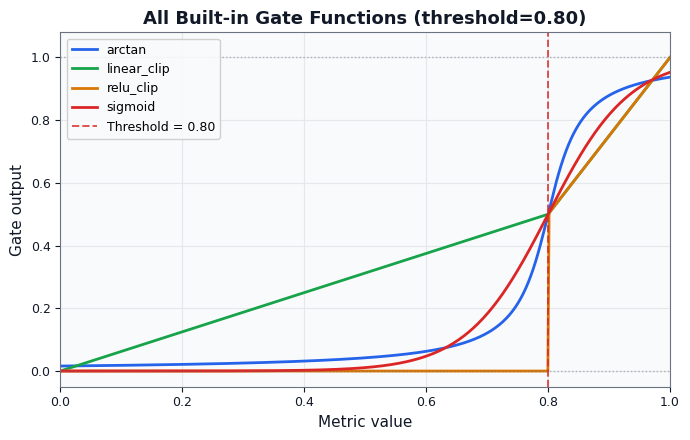

In [13]:
# All 4 built-in gate functions overlaid on a single plot
fig, ax = plot.plot_gate(
    None,  # None → plot all registered gate functions
    threshold=0.80,
    title="All Built-in Gate Functions (threshold=0.80)",
)
plt.show()

### 5f. Effect of the `k` Parameter on Smooth Gates

The steepness parameter `k` controls how sharply the gate transitions around the threshold.

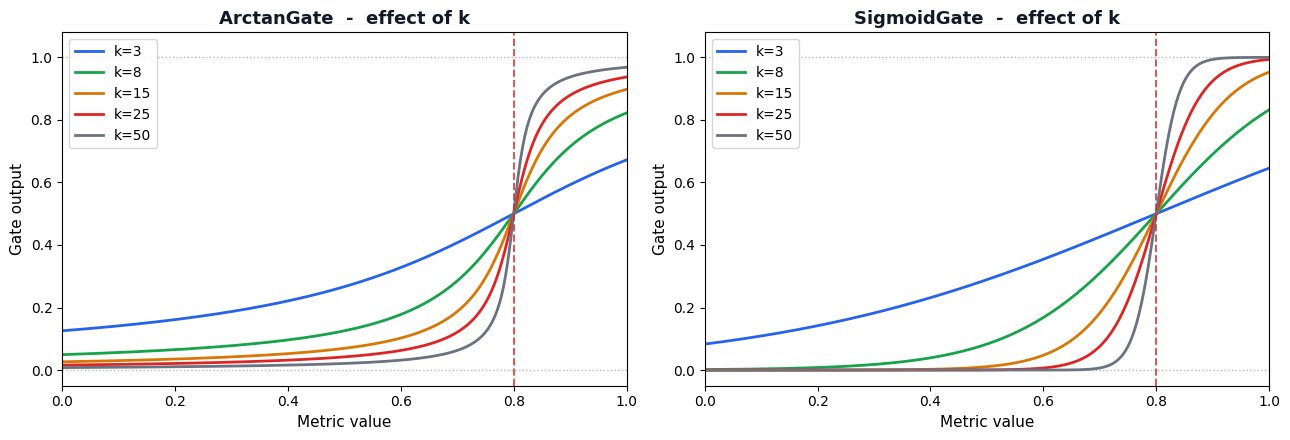

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Arctan with different k values
k_vals = [3, 8, 15, 25, 50]
plot.plot_gate(
    ["arctan"] * 5,
    threshold=0.80,
    gate_params=[{"k": k} for k in k_vals],
    title="ArctanGate  -  effect of k",
    ax=axes[0],
)
# Reuse the plotted artist handles so colors are correct; relabel with k values
h0, _ = axes[0].get_legend_handles_labels()
axes[0].legend(h0[:len(k_vals)], [f"k={k}" for k in k_vals], loc="upper left")

# Sigmoid with different k values
plot.plot_gate(
    ["sigmoid"] * 5,
    threshold=0.80,
    gate_params=[{"k": k} for k in k_vals],
    title="SigmoidGate  -  effect of k",
    ax=axes[1],
)
h1, _ = axes[1].get_legend_handles_labels()
axes[1].legend(h1[:len(k_vals)], [f"k={k}" for k in k_vals], loc="upper left")

plt.tight_layout()
plt.show()

### 5g. Score Comparison Across All Gates

In [15]:
gate_names = gates.list_gates()
print(f"{'Gate':<14} {'Score':>7}  {'Sens Gate':>10}  {'Spec Gate':>10}")
print("-" * 48)
for gate_name in gate_names:
    r = score_from_scores(y_true, y_score, s_thr=0.85, p_thr=0.65, gate=gate_name)
    print(f"{gate_name:<14} {r.score:>7.4f}  {r.sensitivity_gate:>10.4f}  {r.specificity_gate:>10.4f}")

print()
print("Note: all gate functions satisfy gate(thr, thr) = 0.5 (centering property).")

Gate             Score   Sens Gate   Spec Gate
------------------------------------------------
arctan          0.8027      0.7740      0.9399
linear_clip     0.7006      0.6552      0.7988
relu_clip       0.7006      0.6552      0.7988
sigmoid         0.7589      0.6678      0.9584

Note: all gate functions satisfy gate(thr, thr) = 0.5 (centering property).


## 6. Visualization

All six plot helpers return `(Figure, Axes)` and accept an optional `ax` keyword
so you can embed them inside larger subplot grids.

### 6a. Confusion Matrix

`plot_confusion(confusion_matrix)` draws a colour-coded 2×2 matrix with TP/TN/FP/FN annotations.

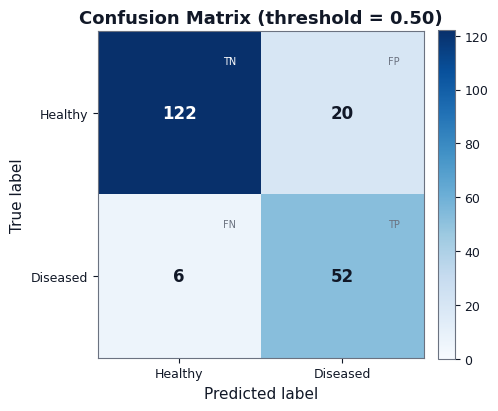

In [16]:
fig, ax = plot.plot_confusion(
    m.confusion_matrix,
    labels=("Healthy", "Diseased"),
    title="Confusion Matrix (threshold = 0.50)",
)
plt.show()

### 6b. Normalised Confusion Matrix

Pass `normalise=True` to display row-normalised fractions instead of raw counts.

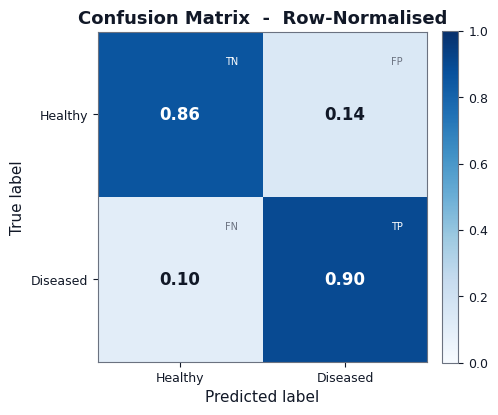

In [17]:
fig, ax = plot.plot_confusion(
    m.confusion_matrix,
    labels=("Healthy", "Diseased"),
    normalise=True,
    title="Confusion Matrix  -  Row-Normalised",
)
plt.show()

### 6c. ROC Curve

`plot_roc(y_true, y_score)` draws the Receiver Operating Characteristic curve with AUC fill.

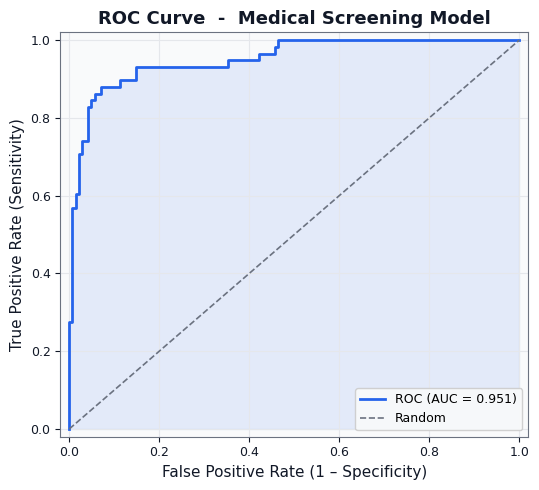

In [18]:
fig, ax = plot.plot_roc(y_true, y_score, title="ROC Curve  -  Medical Screening Model")
plt.show()

### 6d. Precision-Recall Curve

`plot_pr(y_true, y_score)` draws the PR curve with Average Precision and baseline.

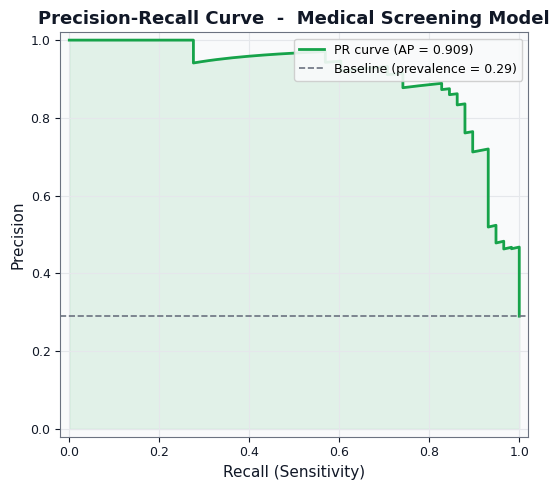

In [19]:
fig, ax = plot.plot_pr(y_true, y_score, title="Precision-Recall Curve  -  Medical Screening Model")
plt.show()

### 6e. Threshold Analysis

`plot_threshold` shows sensitivity, specificity, F1, and accuracy as functions of the decision threshold.
Pass `sensitivity_threshold` and `specificity_threshold` to draw constraint reference lines.

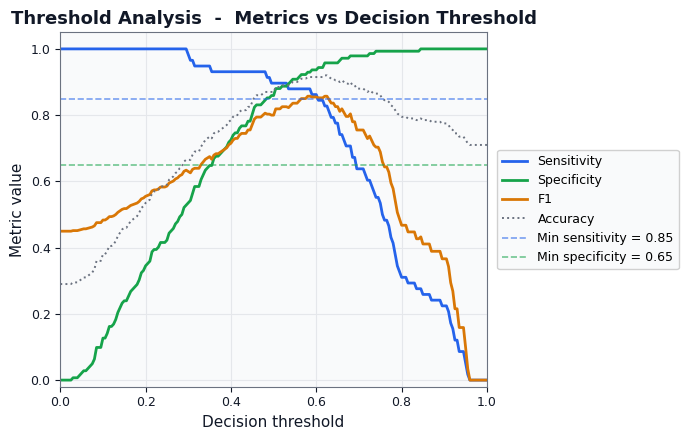

In [20]:
sw = sweep(y_true, y_score, n_thresholds=201)

fig, ax = plot.plot_threshold(
    sw,
    sensitivity_threshold=0.85,
    specificity_threshold=0.65,
    title="Threshold Analysis  -  Metrics vs Decision Threshold",
)
plt.show()

### 6f. Score Heatmap on the Sensitivity–Specificity Plane

`plot_heatmap` renders the full centering-based score surface.
The current model's operating point is marked with a dot.

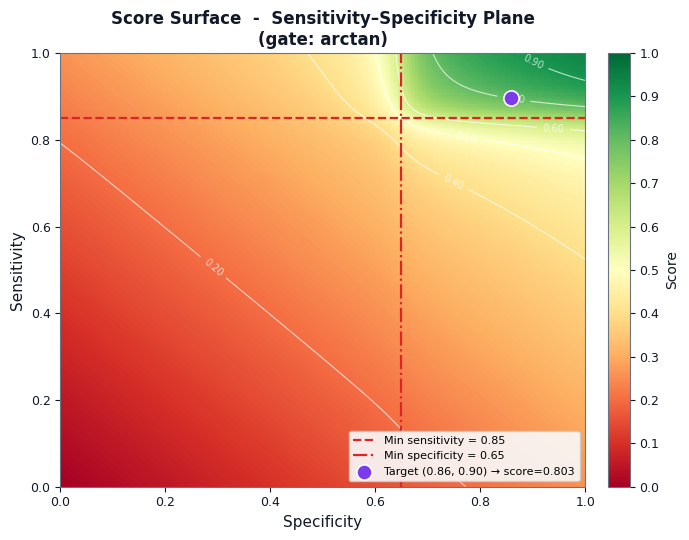

In [21]:
fig, ax = plot.plot_heatmap(
    sensitivity_threshold=0.85,
    specificity_threshold=0.65,
    gate="arctan",
    target_sensitivity=result.sensitivity,
    target_specificity=result.specificity,
    show_contours=True,
    title="Score Surface  -  Sensitivity–Specificity Plane",
)
plt.show()

### 6g. Comparing Score Surfaces Across Gates

Different gates produce very different score landscapes.

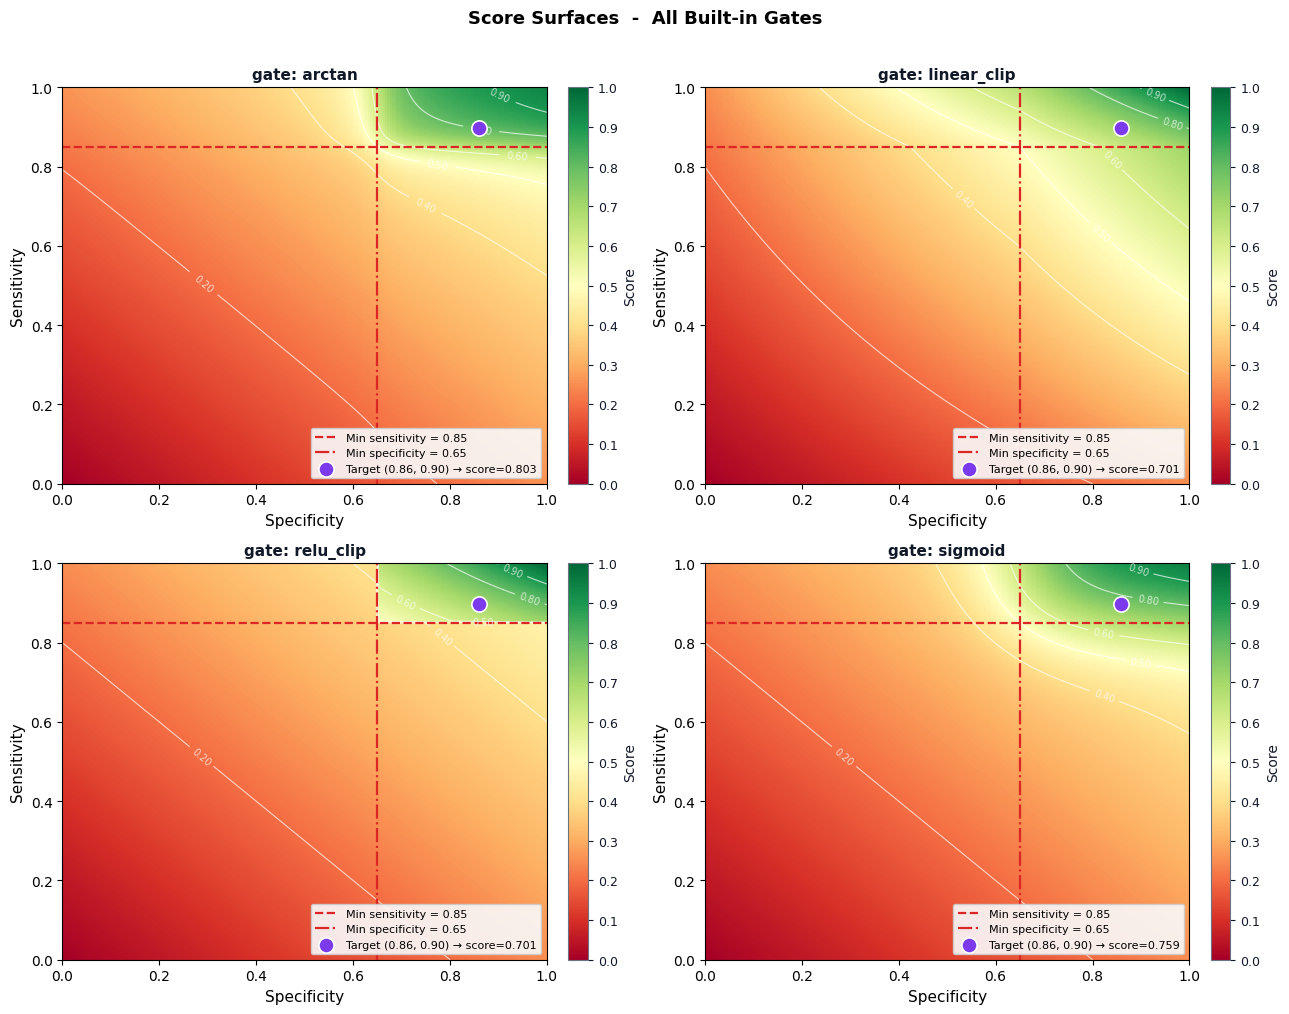

In [22]:
gate_names = gates.list_gates()
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax_i, gate_name in zip(axes.flat, gate_names):
    plot.plot_heatmap(
        sensitivity_threshold=0.85,
        specificity_threshold=0.65,
        gate=gate_name,
        target_sensitivity=result.sensitivity,
        target_specificity=result.specificity,
        show_contours=True,
        title=f"Score Surface",
        ax=ax_i,
    )
    ax_i.set_title(f"gate: {gate_name}", fontsize=11, fontweight="bold")

fig.suptitle("Score Surfaces  -  All Built-in Gates", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 6h. Gate Curves with Custom Thresholds

`plot_gate` can take a single name or instance and a custom threshold.

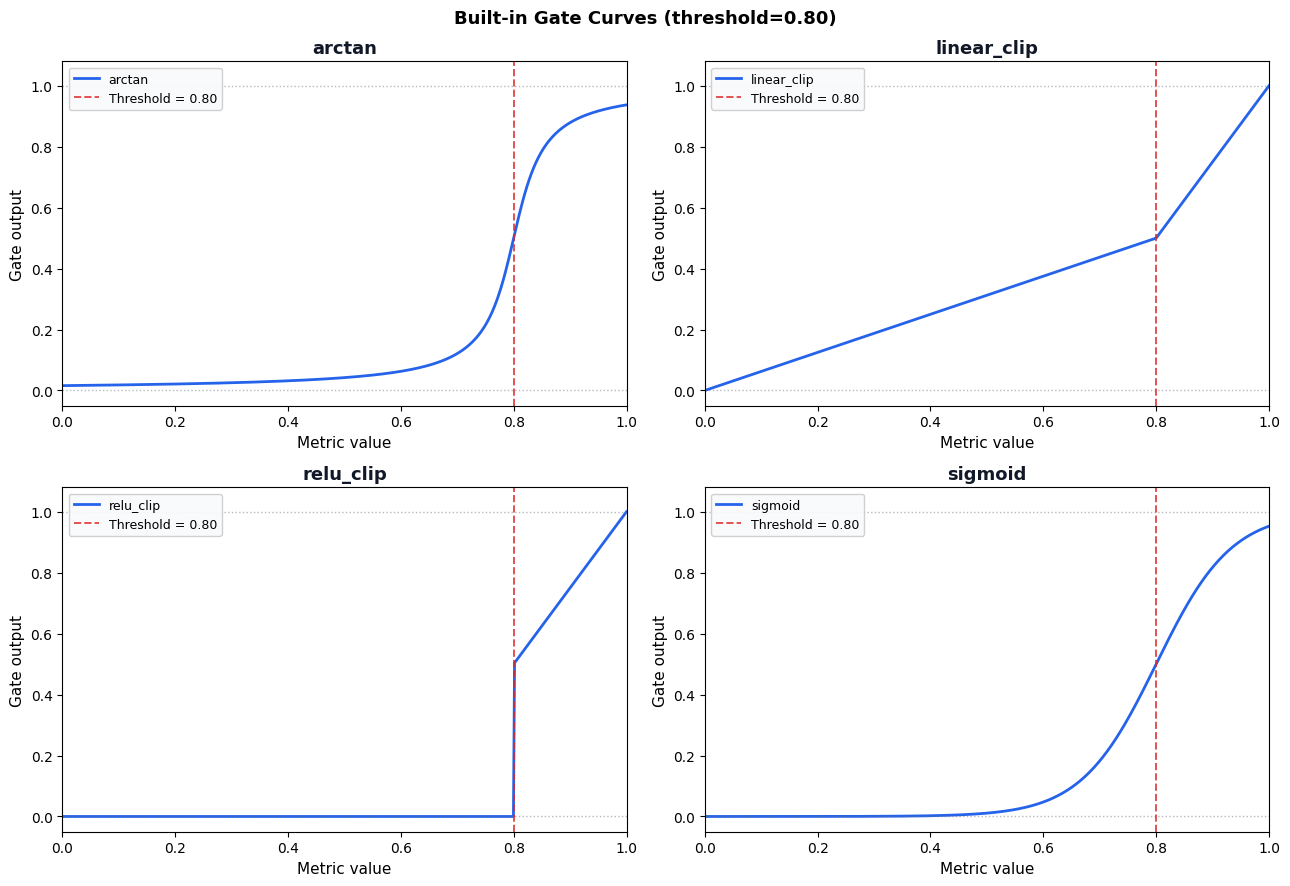

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax_i, gate_name in zip(axes.flat, gate_names):
    plot.plot_gate(
        gate_name,
        threshold=0.80,
        title=f"{gate_name}",
        ax=ax_i,
    )

fig.suptitle("Built-in Gate Curves (threshold=0.80)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Threshold Sweep

`sweep(y_true, y_score, n_thresholds=101)` evaluates classification metrics at
every decision threshold from 0 → 1 and returns a `ThresholdSweep` object.

In [24]:
sw = sweep(y_true, y_score, n_thresholds=201)

print(f"ThresholdSweep: {len(sw.points)} points")
print(f"Threshold range: {sw.thresholds[0]:.2f} → {sw.thresholds[-1]:.2f}")
print()

# --- Best by F1 ---
best_f1 = sw.best_by_f1()
print(f"Best F1 point:")
print(f"  threshold = {best_f1.threshold:.3f}")
print(f"  F1        = {best_f1.f1:.4f}")
print(f"  sens      = {best_f1.sensitivity:.4f}")
print(f"  spec      = {best_f1.specificity:.4f}")
print()

# --- Best sensitivity meeting a specificity floor ---
pt_sens = sw.best_by_sensitivity_at_specificity(min_specificity=0.65)
if pt_sens:
    print(f"Best sensitivity @ spec ≥ 0.65:")
    print(f"  threshold = {pt_sens.threshold:.3f}")
    print(f"  sens      = {pt_sens.sensitivity:.4f}")
    print(f"  spec      = {pt_sens.specificity:.4f}")
print()

# --- Best specificity meeting a sensitivity floor ---
pt_spec = sw.best_by_specificity_at_sensitivity(min_sensitivity=0.85)
if pt_spec:
    print(f"Best specificity @ sens ≥ 0.85:")
    print(f"  threshold = {pt_spec.threshold:.3f}")
    print(f"  sens      = {pt_spec.sensitivity:.4f}")
    print(f"  spec      = {pt_spec.specificity:.4f}")

ThresholdSweep: 201 points
Threshold range: 0.00 → 1.00

Best F1 point:
  threshold = 0.580
  F1        = 0.8571
  sens      = 0.8793
  spec      = 0.9296

Best sensitivity @ spec ≥ 0.65:
  threshold = 0.360
  sens      = 0.9310
  spec      = 0.6690

Best specificity @ sens ≥ 0.85:
  threshold = 0.590
  sens      = 0.8621
  spec      = 0.9366


### ThresholdSweep array attributes

The `ThresholdSweep` object exposes NumPy arrays for vectorised analysis.

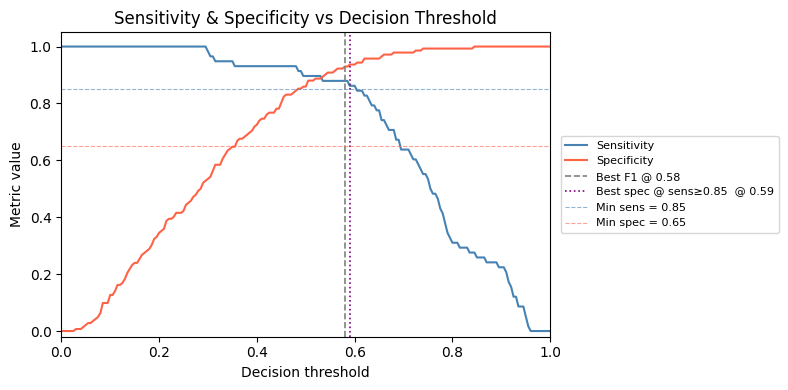

In [25]:
# Plot sensitivity vs specificity as a function of threshold (manual)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sw.thresholds, sw.sensitivities, label="Sensitivity", color="steelblue")
ax.plot(sw.thresholds, sw.specificities, label="Specificity", color="tomato")

# Mark optimal points
ax.axvline(best_f1.threshold, color="gray", linestyle="--", linewidth=1.2, label=f"Best F1 @ {best_f1.threshold:.2f}")
if pt_spec:
    ax.axvline(pt_spec.threshold, color="purple", linestyle=":", linewidth=1.2,
               label=f"Best spec @ sens≥0.85  @ {pt_spec.threshold:.2f}")

ax.axhline(0.85, color="steelblue", linestyle="--", linewidth=0.8, alpha=0.6, label="Min sens = 0.85")
ax.axhline(0.65, color="tomato",    linestyle="--", linewidth=0.8, alpha=0.6, label="Min spec = 0.65")

ax.set_xlabel("Decision threshold")
ax.set_ylabel("Metric value")
ax.set_title("Sensitivity & Specificity vs Decision Threshold")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.show()

### Using `plot_threshold` with constraint reference lines

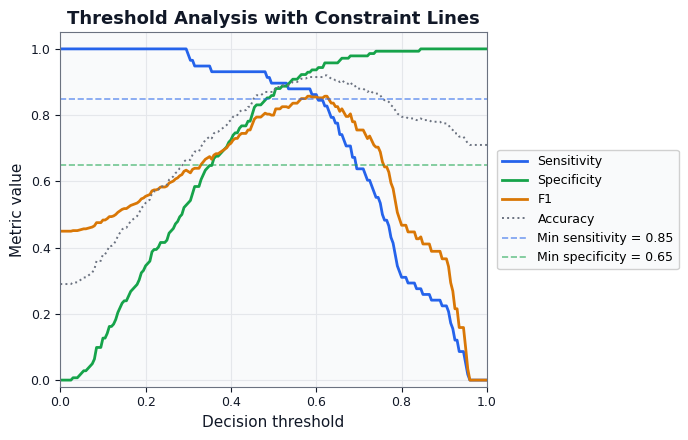

In [26]:
fig, ax = plot.plot_threshold(
    y_true=y_true,
    y_score=y_score,
    n_thresholds=201,
    sensitivity_threshold=0.85,
    specificity_threshold=0.65,
    title="Threshold Analysis with Constraint Lines",
)
plt.show()

## 8. Custom Gate Functions

You can implement your own gate function by subclassing `BaseGate` and
registering it with `register` or `register_class`.

In [27]:
from threshscore.gates import BaseGate, register_class

class StepGate(BaseGate):
    '''Hard binary step: 1.0 if metric >= threshold, else 0.0.

    Most extreme gate - no partial credit, no smooth transition.
    '''

    @property
    def default_params(self):
        return {}

    def __call__(self, value: float, threshold: float, **kwargs) -> float:
        return 1.0 if value >= threshold else 0.0


# Register by class (automatically instantiated)
register_class('step', StepGate)

print('Registered gates after adding step:', gates.list_gates())

r_step = score_from_scores(y_true, y_score, s_thr=0.85, p_thr=0.65, gate='step')
print(f'\nStep gate score: {r_step.score:.4f}')
print(f'  sens={r_step.sensitivity:.4f}  gate={r_step.sensitivity_gate}')
print(f'  spec={r_step.specificity:.4f}  gate={r_step.specificity_gate}')

Registered gates after adding step: ['arctan', 'linear_clip', 'relu_clip', 'sigmoid', 'step']

Step gate score: 0.5639
  sens=0.8966  gate=1.0
  spec=0.8592  gate=1.0


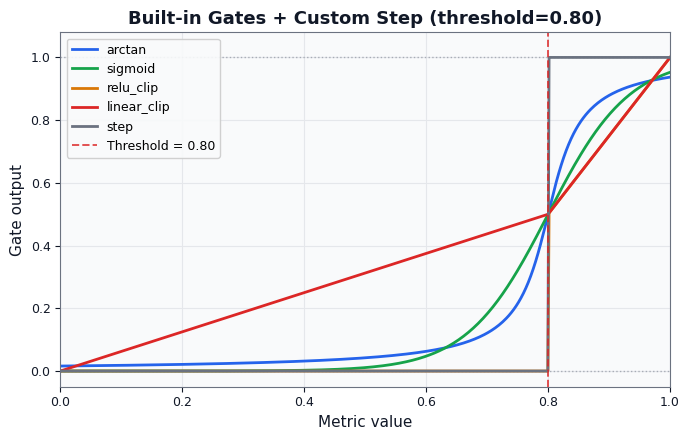

In [28]:
# Visualise the step gate alongside the built-ins
fig, ax = plot.plot_gate(
    ["arctan", "sigmoid", "relu_clip", "linear_clip", "step"],
    threshold=0.80,
    title="Built-in Gates + Custom Step (threshold=0.80)",
)
plt.show()

### Custom gate with tunable parameters

Pass `gate_params` to override default parameters on your custom gate.

soft_step (k=10, default) : 0.7922
soft_step (k=30, steeper) : 0.9101


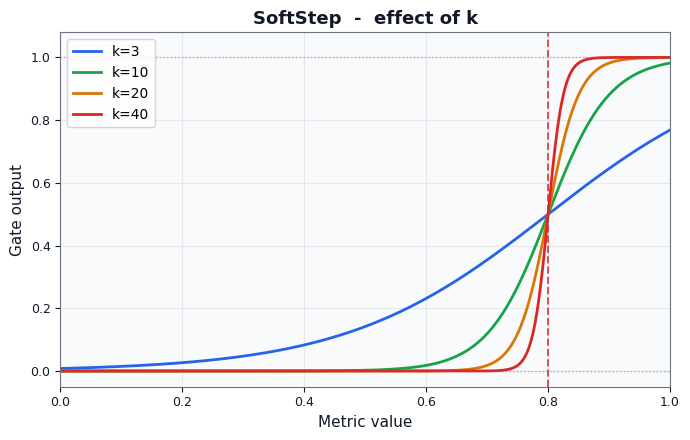

In [29]:
class SoftStepGate(BaseGate):
    '''Soft step via tanh, centred at threshold.

    gate = 0.5 + 0.5 * tanh(k * (value - threshold))
    Default k=10.
    '''

    @property
    def default_params(self):
        return {'k': 10.0}

    def __call__(self, value: float, threshold: float, **params) -> float:
        import math
        p = self._merged_params(**params)
        k = float(p['k'])
        raw = 0.5 + 0.5 * math.tanh(k * (value - threshold))
        return float(max(0.0, min(1.0, raw)))


register_class('soft_step', SoftStepGate)

# Default k
r_ss_default = score_from_scores(
    y_true, y_score, s_thr=0.85, p_thr=0.65, gate='soft_step'
)
# Steeper k
r_ss_steep = score_from_scores(
    y_true, y_score, s_thr=0.85, p_thr=0.65,
    gate='soft_step', gate_params={'k': 30}
)
print(f'soft_step (k=10, default) : {r_ss_default.score:.4f}')
print(f'soft_step (k=30, steeper) : {r_ss_steep.score:.4f}')

# Plot the soft_step with different k values
k_values = [3, 10, 20, 40]
fig, ax = plot.plot_gate(
    ['soft_step'] * 4,
    threshold=0.80,
    gate_params=[{'k': k} for k in k_values],
    title='SoftStep  -  effect of k',
)
# Reuse the plotted artist handles so colors are correct; relabel with k values
ss_handles, _ = ax.get_legend_handles_labels()
ax.legend(ss_handles[:len(k_values)], [f"k={k}" for k in k_values], loc="upper left")
plt.show()

## 9. Summary

### Covered Functions

| Function | Returns | Use when |
|----------|---------|----------|
| `score_from_metrics(sens, spec, ...)` | `float` | You already know sens & spec |
| `score_from_predictions(y_true, y_pred, ...)` | `ScoreResult` | You have hard binary predictions |
| `score_from_scores(y_true, y_score, ...)` | `ScoreResult` | You have probability scores (also gives ROC/PR AUC) |
| `compute_metrics(y_true, y_pred, y_score=None)` | `ClassificationMetrics` | You need the full metric bundle |
| `sweep(y_true, y_score, n_thresholds=101)` | `ThresholdSweep` | Exploring all operating thresholds |

### Covered Gate Functions

| Name | Type | Gate at threshold | Parameter |
|------|------|-------------------|-----------|
| `arctan` | Smooth | 0.5 | `k=25.0` (steepness) |
| `sigmoid` | Smooth | 0.5 | `k=15.0` (steepness) |
| `relu_clip` | Hard | 0.5 |  -  |
| `linear_clip` | Linear | 0.5 |  -  |

### Covered Plots

| Plot helper | What it shows |
|-------------|---------------|
| `plot.plot_confusion(cm)` | 2×2 confusion matrix (raw or normalised) |
| `plot.plot_roc(y_true, y_score)` | ROC curve with AUC |
| `plot.plot_pr(y_true, y_score)` | Precision-Recall curve with AP |
| `plot.plot_threshold(sweep, ...)` | Sensitivity/specificity/F1/accuracy vs threshold |
| `plot.plot_heatmap(...)` | Score surface on the sensitivity–specificity plane |
| `plot.plot_gate(name, ...)` | Gate function curve(s) |

### Threshold Sweep Methods

| Method | Description |
|--------|-------------|
| `sweep.best_by_f1()` | Threshold with highest F1 |
| `sweep.best_by_sensitivity_at_specificity(min_spec)` | Highest sensitivity meeting a specificity floor |
| `sweep.best_by_specificity_at_sensitivity(min_sens)` | Highest specificity meeting a sensitivity floor |

### Key Design Points

- The score equals **0.5 exactly** at the operating point `(s_thr, p_thr)`.
- The score is **> 0.5** when both metrics exceed their thresholds.
- The score is **< 0.5** when either metric falls short.
- All gate functions satisfy `gate(thr, thr) = 0.5` (centering property).
- All plot helpers accept an `ax` kwarg for embedding in larger figure layouts.
- Custom gate functions can be registered and used by name string immediately.

### Next Steps

- See `docs/api_reference.md` for the complete API reference.
- Check `tests/` for examples of edge cases and assertion patterns.
- Use `gates.register` / `gates.register_class` to add project-specific gate functions.